Ciclo   0 | Sanos=7814 | Infectados= 186 | Recuperados=   0 | Muertos=   0
Ciclo   1 | Sanos=7658 | Infectados= 342 | Recuperados=   0 | Muertos=   0
Ciclo   2 | Sanos=7438 | Infectados= 562 | Recuperados=   0 | Muertos=   0
Ciclo   3 | Sanos=7126 | Infectados= 874 | Recuperados=   0 | Muertos=   0
Ciclo   4 | Sanos=6729 | Infectados=1271 | Recuperados=   0 | Muertos=   0
Ciclo   5 | Sanos=6267 | Infectados=1733 | Recuperados=   0 | Muertos=   0
Ciclo   6 | Sanos=5763 | Infectados=2237 | Recuperados=   0 | Muertos=   0
Ciclo   7 | Sanos=5253 | Infectados=2747 | Recuperados=   0 | Muertos=   0
Ciclo   8 | Sanos=4760 | Infectados=3240 | Recuperados=   0 | Muertos=   0
Ciclo   9 | Sanos=4202 | Infectados=3731 | Recuperados=  60 | Muertos=   7
Ciclo  10 | Sanos=3651 | Infectados=4218 | Recuperados= 116 | Muertos=  15
Ciclo  11 | Sanos=3118 | Infectados=4628 | Recuperados= 222 | Muertos=  32
Ciclo  12 | Sanos=2622 | Infectados=4934 | Recuperados= 388 | Muertos=  56
Ciclo  13 | Sanos=2155 | 

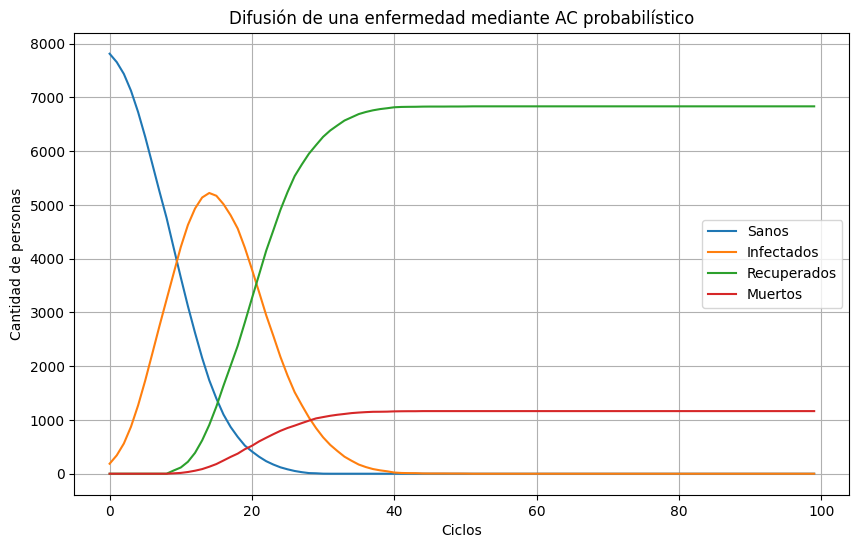

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# PARÁMETROS DEL MODELO

FILAS = 100
COLUMNAS = 100
CICLOS = 100

# ESTADOS

VACIO = 0
SANO = 1
INFECTADO = 2
RECUPERADO = 3
MUERTO = 4

# MATRIZ PRINCIPAL

mundo = np.zeros((FILAS, COLUMNAS), dtype=int)

# CONTADOR DE DÍAS INFECTADO

dias_infectado = np.zeros((FILAS, COLUMNAS), dtype=int)

# CONFIGURACIÓN INICIAL

celdas = [(i, j) for i in range(FILAS) for j in range(COLUMNAS)]
random.shuffle(celdas)

# ASIGNAR PERSONAS SANAS

for i in range(7900):
    x, y = celdas[i]
    mundo[x, y] = SANO

# ASIGNAR PERSONAS INFECTADAS

for i in range(7900, 8000):
    x, y = celdas[i]
    mundo[x, y] = INFECTADO

# FUNCIÓN VECINDAD DE MOORE

def vecinos_moore(x, y):

    vecinos = []

    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:

            if dx == 0 and dy == 0:
                continue

            nx = (x + dx) % FILAS
            ny = (y + dy) % COLUMNAS

            vecinos.append((nx, ny))

    return vecinos

# FUNCIÓN DE MOVIMIENTO

def mover_personas(matriz):

    nueva = matriz.copy()

    for x in range(FILAS):
        for y in range(COLUMNAS):

            if matriz[x, y] in [SANO, INFECTADO, RECUPERADO]:

                if random.random() < 0.25:

                    movimientos = [
                        (-1, 0),
                        (1, 0),
                        (0, -1),
                        (0, 1)
                    ]

                    dx, dy = random.choice(movimientos)

                    nx = (x + dx) % FILAS
                    ny = (y + dy) % COLUMNAS

                    if nueva[nx, ny] == VACIO:

                        nueva[nx, ny] = nueva[x, y]
                        nueva[x, y] = VACIO

    return nueva

# HISTORIAL DE ESTADÍSTICAS

hist_sanos = []
hist_infectados = []
hist_recuperados = []
hist_muertos = []

# INICIO DE LA SIMULACIÓN

for ciclo in range(CICLOS):

    nuevo_mundo = mundo.copy()

    # RECORRER TODAS LAS CELDAS

    for x in range(FILAS):
        for y in range(COLUMNAS):

            estado = mundo[x, y]

            # PROCESO DE CONTAGIO

            if estado == SANO:

                vecinos = vecinos_moore(x, y)

                infectados = 0

                # CONTAR VECINOS INFECTADOS

                for vx, vy in vecinos:

                    if mundo[vx, vy] == INFECTADO:
                        infectados += 1

                # ASIGNAR PROBABILIDAD DE CONTAGIO

                if infectados == 1:
                    prob = 0.15

                elif infectados == 2:
                    prob = 0.30

                elif infectados >= 3:
                    prob = 0.60

                else:
                    prob = 0

                # REALIZAR CONTAGIO

                if random.random() < prob:
                    nuevo_mundo[x, y] = INFECTADO

            # EVOLUCIÓN DE LA ENFERMEDAD

            elif estado == INFECTADO:

                dias_infectado[x, y] += 1

                # RECUPERACIÓN O MUERTE

                if dias_infectado[x, y] >= 10:

                    if random.random() < 0.85:
                        nuevo_mundo[x, y] = RECUPERADO

                    else:
                        nuevo_mundo[x, y] = MUERTO

    # ACTUALIZAR MUNDO

    mundo = nuevo_mundo

    # MOVIMIENTO DE PERSONAS

    mundo = mover_personas(mundo)

    # CÁLCULO DE ESTADÍSTICAS

    sanos = np.sum(mundo == SANO)
    infectados = np.sum(mundo == INFECTADO)
    recuperados = np.sum(mundo == RECUPERADO)
    muertos = np.sum(mundo == MUERTO)

    # ALMACENAR HISTORIAL

    hist_sanos.append(sanos)
    hist_infectados.append(infectados)
    hist_recuperados.append(recuperados)
    hist_muertos.append(muertos)

    # MOSTRAR RESULTADOS DEL CICLO

    print(
        f"Ciclo {ciclo:3d} | "
        f"Sanos={sanos:4d} | "
        f"Infectados={infectados:4d} | "
        f"Recuperados={recuperados:4d} | "
        f"Muertos={muertos:4d}"
    )

# GRAFICAR RESULTADOS

plt.figure(figsize=(10, 6))

plt.plot(hist_sanos, label="Sanos")
plt.plot(hist_infectados, label="Infectados")
plt.plot(hist_recuperados, label="Recuperados")
plt.plot(hist_muertos, label="Muertos")

# CONFIGURACIÓN DE LA GRÁFICA

plt.xlabel("Ciclos")
plt.ylabel("Cantidad de personas")
plt.title("Difusión de una enfermedad mediante AC probabilístico")
plt.legend()
plt.grid(True)

# MOSTRAR GRÁFICA

plt.show()
